Starting Training Loop...
[Epoch 1/25] [D loss: 0.3841] [G loss: 2.4322]
[Epoch 2/25] [D loss: 0.2462] [G loss: 3.4989]
[Epoch 3/25] [D loss: 0.2699] [G loss: 2.9422]
[Epoch 4/25] [D loss: 0.2883] [G loss: 2.6814]
[Epoch 5/25] [D loss: 0.3255] [G loss: 2.3239]
[Epoch 6/25] [D loss: 0.3629] [G loss: 2.1100]
[Epoch 7/25] [D loss: 0.3853] [G loss: 1.9093]
[Epoch 8/25] [D loss: 0.4314] [G loss: 1.6962]
[Epoch 9/25] [D loss: 0.4589] [G loss: 1.5502]
[Epoch 10/25] [D loss: 0.5023] [G loss: 1.3619]
[Epoch 11/25] [D loss: 0.5158] [G loss: 1.3203]
[Epoch 12/25] [D loss: 0.5308] [G loss: 1.2649]
[Epoch 13/25] [D loss: 0.5411] [G loss: 1.2262]
[Epoch 14/25] [D loss: 0.5543] [G loss: 1.1760]
[Epoch 15/25] [D loss: 0.5690] [G loss: 1.1258]
[Epoch 16/25] [D loss: 0.5837] [G loss: 1.0727]
[Epoch 17/25] [D loss: 0.5897] [G loss: 1.0540]
[Epoch 18/25] [D loss: 0.5972] [G loss: 1.0245]
[Epoch 19/25] [D loss: 0.6048] [G loss: 1.0016]
[Epoch 20/25] [D loss: 0.6099] [G loss: 0.9835]
[Epoch 21/25] [D loss: 

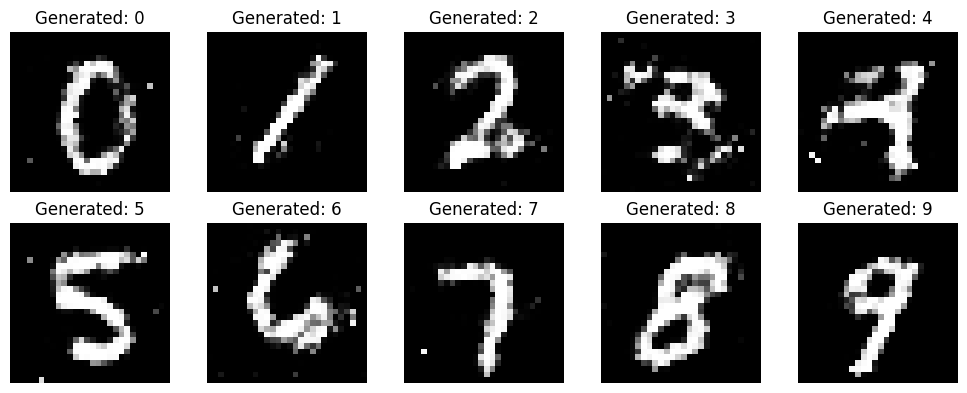

In [2]:
# Exp 6 : Conditional GAN (CGAN) Network

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ==============================
# HYPERPARAMETERS
# ==============================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr = 0.0002
beta1 = 0.5
batch_size = 128
epochs = 25
z_dim = 100
num_classes = 10
img_size = 28 * 28

# ==============================
# DATASET
# ==============================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ==============================
# GENERATOR
# ==============================
class Generator(nn.Module):
    def __init__(self, z_dim, num_classes, img_size):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(z_dim + num_classes, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, img_size),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        c = self.label_emb(labels)
        x = torch.cat([noise, c], dim=1)
        img = self.model(x)
        return img

# ==============================
# DISCRIMINATOR
# ==============================
class Discriminator(nn.Module):
    def __init__(self, num_classes, img_size):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(img_size + num_classes, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        c = self.label_emb(labels)
        img_flat = img.view(img.size(0), -1)
        x = torch.cat([img_flat, c], dim=1)
        validity = self.model(x)
        return validity

# ==============================
# INITIALIZE MODELS
# ==============================
G = Generator(z_dim, num_classes, img_size).to(device)
D = Discriminator(num_classes, img_size).to(device)

# ==============================
# LOSS & OPTIMIZERS
# ==============================
criterion = nn.BCELoss()

g_optimizer = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
d_optimizer = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

print("Starting Training Loop...")

# ==============================
# TRAINING LOOP
# ==============================
for epoch in range(epochs):
    total_d_loss = 0
    total_g_loss = 0

    for imgs, labels in dataloader:
        cur_batch_size = imgs.size(0)

        real = torch.ones(cur_batch_size, 1).to(device)
        fake = torch.zeros(cur_batch_size, 1).to(device)

        real_imgs = imgs.to(device)
        labels = labels.to(device)

        # ======================
        # TRAIN DISCRIMINATOR
        # ======================
        d_optimizer.zero_grad()

        real_output = D(real_imgs, labels)
        d_loss_real = criterion(real_output, real)

        z = torch.randn(cur_batch_size, z_dim).to(device)
        fake_imgs = G(z, labels)

        fake_output = D(fake_imgs.detach(), labels)
        d_loss_fake = criterion(fake_output, fake)

        d_loss = (d_loss_real + d_loss_fake) / 2
        d_loss.backward()
        d_optimizer.step()

        total_d_loss += d_loss.item()

        # ======================
        # TRAIN GENERATOR
        # ======================
        g_optimizer.zero_grad()

        z = torch.randn(cur_batch_size, z_dim).to(device)
        gen_imgs = G(z, labels)

        output = D(gen_imgs, labels)
        g_loss = criterion(output, real)

        g_loss.backward()
        g_optimizer.step()

        total_g_loss += g_loss.item()

    avg_d_loss = total_d_loss / len(dataloader)
    avg_g_loss = total_g_loss / len(dataloader)

    print(f"[Epoch {epoch+1}/{epochs}] [D loss: {avg_d_loss:.4f}] [G loss: {avg_g_loss:.4f}]")

print("Training Finished.")

# ==============================
# GENERATE DIGITS
# ==============================
def generate_digit(digit):
    G.eval()
    z = torch.randn(1, z_dim).to(device)
    label = torch.LongTensor([digit]).to(device)

    with torch.no_grad():
        generated_img = G(z, label)

    img = generated_img.view(28, 28).cpu().numpy()
    img = (img * 0.5) + 0.5  # Rescale to [0,1]

    return img

# ==============================
# VISUALIZE RESULTS
# ==============================
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = generate_digit(i)
    plt.imshow(img, cmap='gray')
    plt.title(f"Generated: {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()